**Cricket Performance Analytics Project**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

LOADING ALL DATASETS

In [2]:
# ODI DATASETS
odi_batting = pd.read_csv('/content/odb.csv')
odi_bowling = pd.read_csv('/content/odbo.csv')
odi_tournament = pd.read_csv('/content/odt.csv')

# TEST DATASETS
test_batting = pd.read_csv('/content/tb.csv')
test_bowling = pd.read_csv('/content/tbo.csv')
test_tournament = pd.read_csv('/content/tt.csv')

# T20 DATASETS
t20_batting = pd.read_csv('/content/twb.csv')
t20_bowling = pd.read_csv('/content/twbo.csv')
t20_tournament = pd.read_csv('/content/twt.csv')

VIEWING DATASETS

In [3]:
print("ODI Batting Dataset")
odi_batting.head()

print("ODI Bowling Dataset")
odi_bowling.head()

print("Test Batting Dataset")
test_batting.head()

print("T20 Batting Dataset")
t20_batting.head()

ODI Batting Dataset
ODI Bowling Dataset
Test Batting Dataset
T20 Batting Dataset


,Unnamed: 0,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,4s,6s
0,0,MJ Guptill (NZ),2009-2021,112,108,7,3299,105,32.66,2413,136.71,2,20,3,287,165
1,1,V Kohli (INDIA),2010-2021,95,87,25,3227,94*,52.04,2340,137.90,0,29,3,290,91
2,2,RG Sharma (INDIA),2007-2021,119,111,15,3197,118,33.30,2279,140.28,4,26,7,284,150
3,3,Babar Azam (PAK),2016-2021,73,68,10,2620,122,45.17,2029,129.12,1,25,3,272,40
4,4,AJ Finch (AUS),2011-2021,83,83,10,2608,172,35.72,1762,148.01,2,15,7,261,113


CHECKING DATASET INFORMATION

In [4]:
odi_batting.info()

odi_bowling.info()

test_batting.info()

t20_batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  119 non-null    int64  
 1   Player      119 non-null    object 
 2   Span        119 non-null    object 
 3   Mat         119 non-null    int64  
 4   Inns        119 non-null    int64  
 5   NO          119 non-null    int64  
 6   Runs        119 non-null    int64  
 7   HS          119 non-null    object 
 8   Ave         119 non-null    float64
 9   BF          119 non-null    int64  
 10  SR          119 non-null    float64
 11  100         119 non-null    int64  
 12  50          119 non-null    int64  
 13  0           119 non-null    int64  
 14  4s          119 non-null    object 
 15  6s          119 non-null    object 
dtypes: float64(2), int64(9), object(5)
memory usage: 15.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 14 c

CHECK COLLUMN NAMES

In [5]:
print("ODI Batting Columns")
print(odi_batting.columns)

print("ODI Bowling Columns")
print(odi_bowling.columns)

ODI Batting Columns
Index(['Unnamed: 0', 'Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS',
       'Ave', 'BF', 'SR', '100', '50', '0', '4s', '6s'],
      dtype='object')
ODI Bowling Columns
Index(['Unnamed: 0', 'Player', 'Span', 'Mat', 'Inns', 'Balls', 'Runs', 'Wkts',
       'BBI', 'Ave', 'Econ', 'SR', '4', '5'],
      dtype='object')


DATA CLEANING

In [6]:
# Remove unnamed columns
odi_batting = odi_batting.loc[:, ~odi_batting.columns.str.contains('^Unnamed')]

# Remove duplicate rows
odi_batting.drop_duplicates(inplace=True)

# Fill missing values
odi_batting.fillna(0, inplace=True)

# View cleaned dataset
odi_batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  119 non-null    object 
 1   Span    119 non-null    object 
 2   Mat     119 non-null    int64  
 3   Inns    119 non-null    int64  
 4   NO      119 non-null    int64  
 5   Runs    119 non-null    int64  
 6   HS      119 non-null    object 
 7   Ave     119 non-null    float64
 8   BF      119 non-null    int64  
 9   SR      119 non-null    float64
 10  100     119 non-null    int64  
 11  50      119 non-null    int64  
 12  0       119 non-null    int64  
 13  4s      119 non-null    object 
 14  6s      119 non-null    object 
dtypes: float64(2), int64(8), object(5)
memory usage: 14.1+ KB


CLEANING ODI BOWLING

In [7]:
odi_bowling = odi_bowling.loc[:, ~odi_bowling.columns.str.contains('^Unnamed')]

odi_bowling.drop_duplicates(inplace=True)

odi_bowling.fillna(0, inplace=True)

odi_bowling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  76 non-null     object 
 1   Span    76 non-null     object 
 2   Mat     76 non-null     int64  
 3   Inns    76 non-null     int64  
 4   Balls   76 non-null     int64  
 5   Runs    76 non-null     int64  
 6   Wkts    76 non-null     int64  
 7   BBI     76 non-null     object 
 8   Ave     76 non-null     float64
 9   Econ    76 non-null     float64
 10  SR      76 non-null     float64
 11  4       76 non-null     int64  
 12  5       76 non-null     int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 7.8+ KB


CLEANING TEST BATTING

In [8]:
test_batting = test_batting.loc[:, ~test_batting.columns.str.contains('^Unnamed')]

test_batting.drop_duplicates(inplace=True)

test_batting.fillna(0, inplace=True)

test_batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  97 non-null     object 
 1   Span    97 non-null     object 
 2   Mat     97 non-null     object 
 3   Inns    97 non-null     int64  
 4   NO      97 non-null     int64  
 5   Runs    97 non-null     int64  
 6   HS      97 non-null     object 
 7   Ave     97 non-null     float64
 8   100     97 non-null     int64  
 9   50      97 non-null     int64  
 10  0       97 non-null     int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 8.5+ KB


CLEANING TEST BOWLING

In [9]:
test_bowling = test_bowling.loc[:, ~test_bowling.columns.str.contains('^Unnamed')]

test_bowling.drop_duplicates(inplace=True)

test_bowling.fillna(0, inplace=True)

test_bowling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     object 
 3   Inns    79 non-null     int64  
 4   Balls   79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   Wkts    79 non-null     int64  
 7   BBI     79 non-null     object 
 8   BBM     79 non-null     object 
 9   Ave     79 non-null     float64
 10  Econ    79 non-null     float64
 11  SR      79 non-null     float64
 12  5       79 non-null     int64  
 13  10      79 non-null     int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 8.8+ KB


CLEANING T20 BATTING

In [10]:
t20_batting = t20_batting.loc[:, ~t20_batting.columns.str.contains('^Unnamed')]

t20_batting.drop_duplicates(inplace=True)

t20_batting.fillna(0, inplace=True)

t20_batting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  105 non-null    object 
 1   Span    105 non-null    object 
 2   Mat     105 non-null    int64  
 3   Inns    105 non-null    int64  
 4   NO      105 non-null    int64  
 5   Runs    105 non-null    int64  
 6   HS      105 non-null    object 
 7   Ave     105 non-null    float64
 8   BF      105 non-null    int64  
 9   SR      105 non-null    float64
 10  100     105 non-null    int64  
 11  50      105 non-null    int64  
 12  0       105 non-null    int64  
 13  4s      105 non-null    int64  
 14  6s      105 non-null    int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 12.4+ KB


CLEANING T20 BOWLING

In [11]:
t20_bowling = t20_bowling.loc[:, ~t20_bowling.columns.str.contains('^Unnamed')]

t20_bowling.drop_duplicates(inplace=True)

t20_bowling.fillna(0, inplace=True)

t20_bowling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  181 non-null    object 
 1   Span    181 non-null    object 
 2   Mat     181 non-null    int64  
 3   Inns    181 non-null    int64  
 4   Overs   181 non-null    float64
 5   Mdns    181 non-null    int64  
 6   Runs    181 non-null    int64  
 7   Wkts    181 non-null    int64  
 8   BBI     181 non-null    object 
 9   Ave     181 non-null    float64
 10  Econ    181 non-null    float64
 11  SR      181 non-null    float64
 12  4       181 non-null    int64  
 13  5       181 non-null    int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 19.9+ KB


CHECKING MISSING VALUES

In [12]:
odi_batting.isnull().sum()

odi_bowling.isnull().sum()

,0
Player,0
Span,0
Mat,0
Inns,0
Balls,0
Runs,0
Wkts,0
BBI,0
Ave,0
Econ,0


SAVING CLEANED DATASETS

In [13]:
odi_batting.to_csv('cleaned_odi_batting.csv', index=False)
odi_bowling.to_csv('cleaned_odi_bowling.csv', index=False)

test_batting.to_csv('cleaned_test_batting.csv', index=False)
test_bowling.to_csv('cleaned_test_bowling.csv', index=False)

t20_batting.to_csv('cleaned_t20_batting.csv', index=False)
t20_bowling.to_csv('cleaned_t20_bowling.csv', index=False)

CREATING EXCEL FILES

In [14]:
with pd.ExcelWriter('Cricket_Analytics_Dataset.xlsx') as writer:
    odi_batting.to_excel(writer, sheet_name='ODI_Batting', index=False)
    odi_bowling.to_excel(writer, sheet_name='ODI_Bowling', index=False)
    test_batting.to_excel(writer, sheet_name='Test_Batting', index=False)
    test_bowling.to_excel(writer, sheet_name='Test_Bowling', index=False)
    t20_batting.to_excel(writer, sheet_name='T20_Batting', index=False)
    t20_bowling.to_excel(writer, sheet_name='T20_Bowling', index=False)

print("Excel file created successfully")

Excel file created successfully


In [15]:
odi_batting.columns

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', '4s', '6s'],
      dtype='object')

TOP RUN SCORERS ANALYSIS

In [16]:
top_runs = odi_batting.sort_values(by='Runs', ascending=False).head(10)

print(top_runs)

                         Player       Span  Mat  Inns  NO   Runs    HS    Ave  \
0          SR Tendulkar (INDIA)  1989-2012  463   452  41  18426  200*  44.83   
8   KC Sangakkara (Asia/ICC/SL)  2000-2015  404   380  41  14234   169  41.98   
2          RT Ponting (AUS/ICC)  1995-2012  375   365  39  13704   164  42.03   
4       ST Jayasuriya (Asia/SL)  1989-2011  445   433  18  13430   189  32.36   
15   DPMD Jayawardene (Asia/SL)  1998-2015  448   418  39  12650   144  33.37   
1               V Kohli (INDIA)  2008-2021  254   245  39  12169   183  59.07   
57    Inzamam-ul-Haq (Asia/PAK)  1991-2007  378   350  53  11739  137*  39.52   
21       JH Kallis (Afr/ICC/SA)  1996-2014  328   314  53  11579   139  44.36   
9       SC Ganguly (Asia/INDIA)  1992-2007  311   300  23  11363   183  41.02   
39    R Dravid (Asia/ICC/INDIA)  1996-2011  344   318  40  10889   153  39.16   

       BF     SR  100  50   0    4s   6s  
0   21368  86.23   49  96  20  2016  195  
8   18048  78.86   25 

VISUALIZATION OF TOP RUN SCORERS

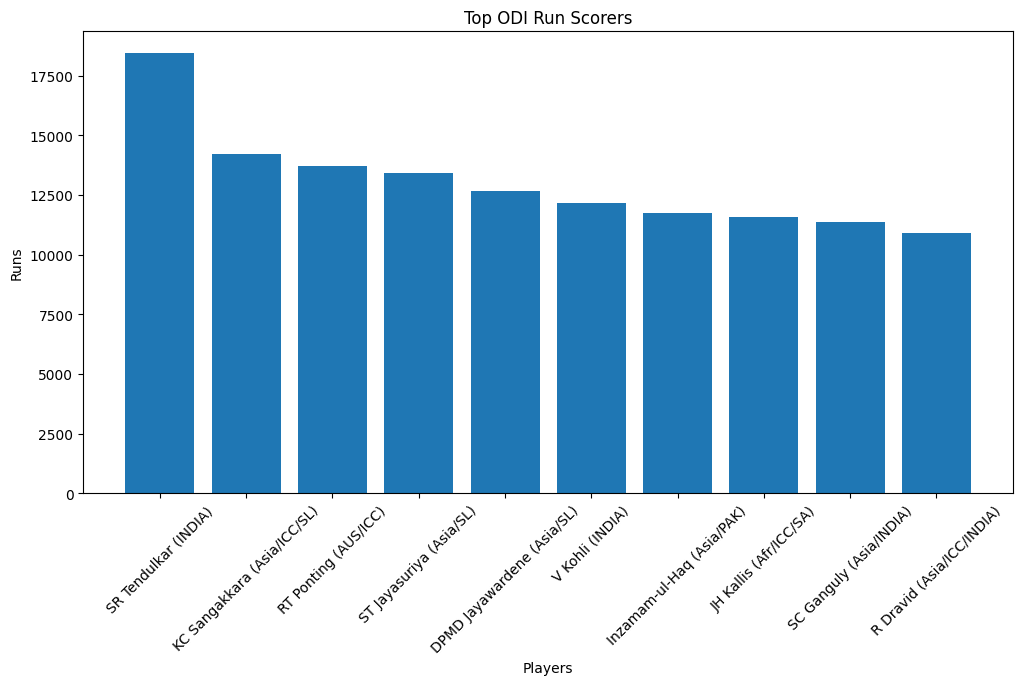

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(top_runs['Player'], top_runs['Runs'])

plt.xticks(rotation=45)

plt.title('Top ODI Run Scorers')

plt.xlabel('Players')

plt.ylabel('Runs')

plt.show()

TOP WICKET TAKERS

In [17]:
top_wickets = odi_bowling.sort_values(by='Wkts', ascending=False).head(10)

print(top_wickets)

                         Player       Span  Mat  Inns  Balls   Runs  Wkts  \
0  M Muralitharan (Asia/ICC/SL)  1993-2011  350   341  18811  12326   534   
1             Wasim Akram (PAK)  1984-2003  356   351  18186  11812   502   
2            Waqar Younis (PAK)  1989-2003  262   258  12698   9919   416   
3          WPUJC Vaas (Asia/SL)  1994-2008  322   320  15775  11014   400   
4  Shahid Afridi (Asia/ICC/PAK)  1996-2015  398   372  17670  13632   395   
5       SM Pollock (Afr/ICC/SA)  1996-2008  303   297  15712   9631   393   
6          GD McGrath (AUS/ICC)  1993-2007  250   248  12970   8391   381   
7                   B Lee (AUS)  2000-2012  221   217  11185   8877   380   
8               SL Malinga (SL)  2004-2019  226   220  10936   9760   338   
9         A Kumble (Asia/INDIA)  1990-2007  271   265  14496  10412   337   

    BBI    Ave  Econ    SR   4   5  
0  7/30  23.08  3.93  35.2  15  10  
1  5/15  23.52  3.89  36.2  17   6  
2  7/36  23.84  4.68  30.5  14  13  
3  8

VISUALIZATION OF TOP WICKET TAKERS

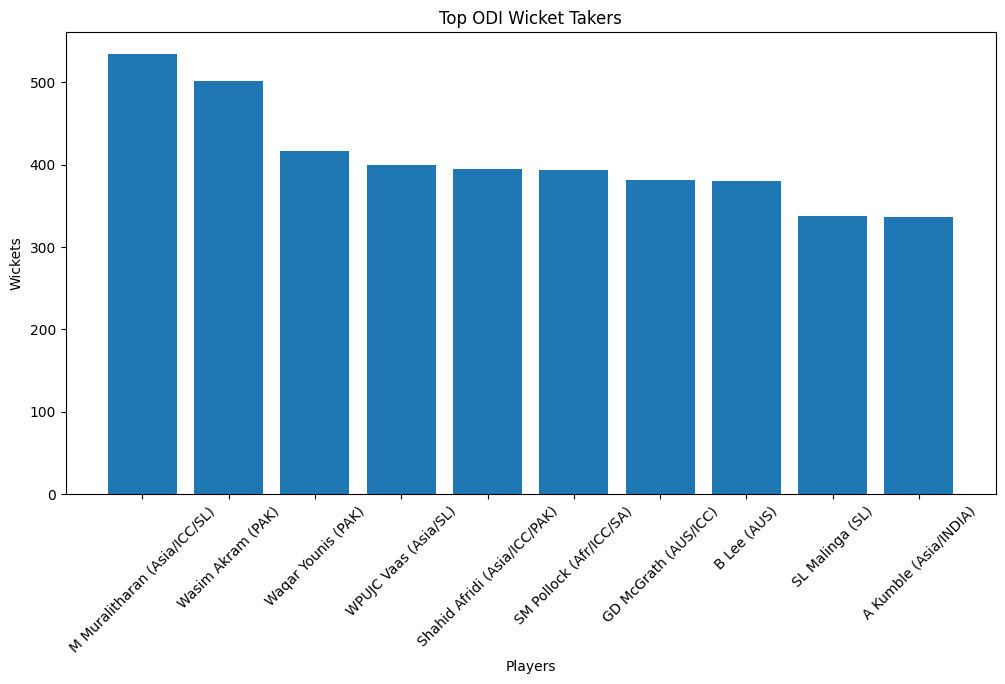

In [18]:
plt.figure(figsize=(12,6))

plt.bar(top_wickets['Player'], top_wickets['Wkts'])

plt.xticks(rotation=45)

plt.title('Top ODI Wicket Takers')

plt.xlabel('Players')

plt.ylabel('Wickets')

plt.show()

COMPARE FORMATS

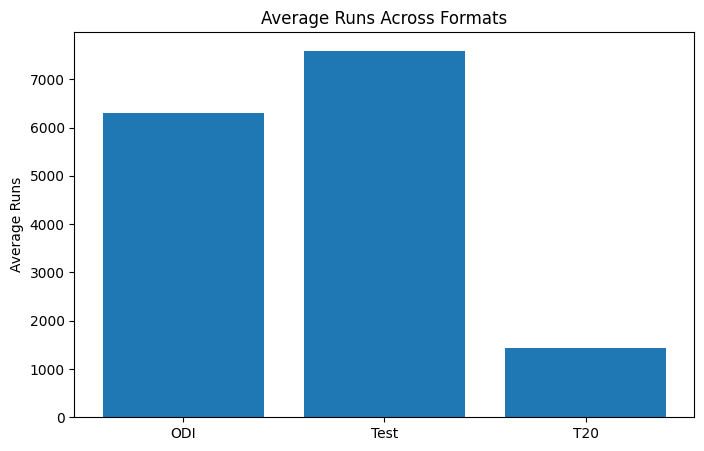

In [19]:
formats = ['ODI', 'Test', 'T20']

avg_runs = [
    odi_batting['Runs'].mean(),
    test_batting['Runs'].mean(),
    t20_batting['Runs'].mean()
]

plt.figure(figsize=(8,5))

plt.bar(formats, avg_runs)

plt.title('Average Runs Across Formats')

plt.ylabel('Average Runs')

plt.show()

CORRELATION HEATMAP

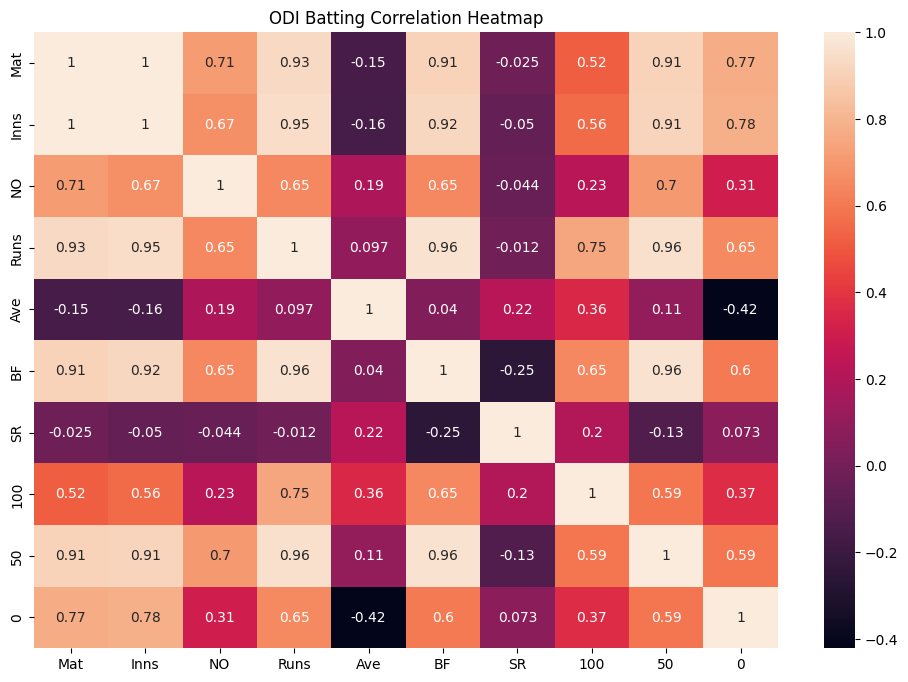

In [20]:
numeric_cols = odi_batting.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(numeric_cols.corr(), annot=True)

plt.title('ODI Batting Correlation Heatmap')

plt.show()

CREATE PLAYER EFFICIENCY SCORE

In [21]:
odi_batting.columns

Index(['Player', 'Span', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR',
       '100', '50', '0', '4s', '6s'],
      dtype='object')

In [22]:
odi_batting['Efficiency_Score'] = (
    odi_batting['Runs'] * odi_batting['SR']
)

odi_batting[['Player', 'Efficiency_Score']].head()

,Player,Efficiency_Score
0,SR Tendulkar (INDIA),1588873.98
1,V Kohli (INDIA),1133785.73
2,RT Ponting (AUS/ICC),1101664.56
3,RG Sharma (INDIA),818324.50
4,ST Jayasuriya (Asia/SL),1224816.00


TOP EFFICIENCY PLAYERS

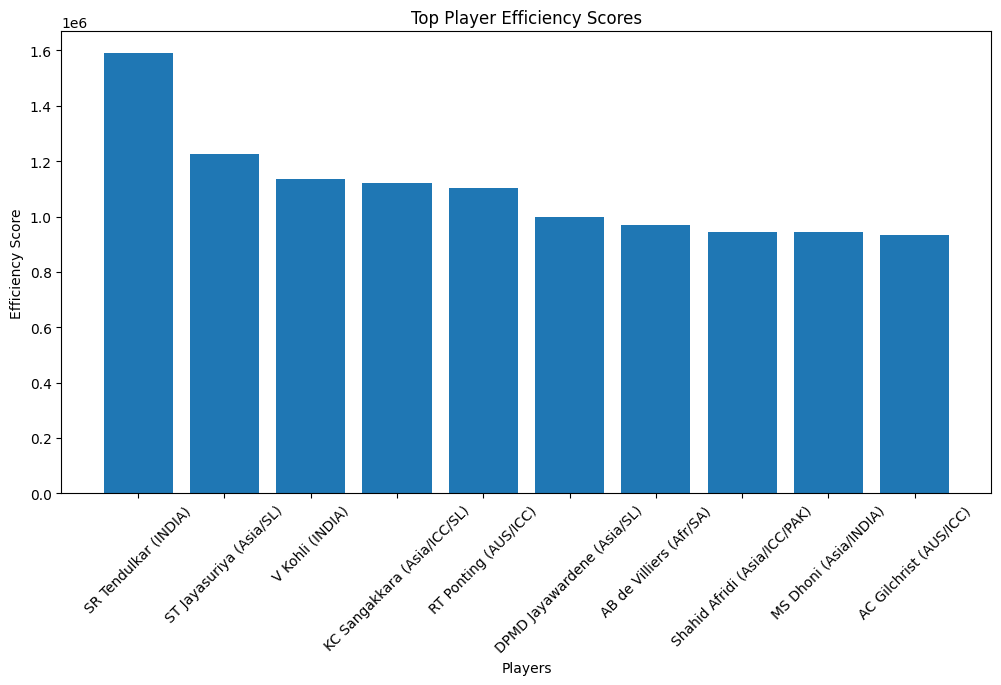

In [23]:
top_efficiency = odi_batting.sort_values(
    by='Efficiency_Score',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_efficiency['Player'], top_efficiency['Efficiency_Score'])

plt.xticks(rotation=45)

plt.title('Top Player Efficiency Scores')

plt.xlabel('Players')

plt.ylabel('Efficiency Score')

plt.show()

EXPORT FINAL CLEANED DATA

In [24]:
with pd.ExcelWriter('Final_Cricket_Analytics_Project.xlsx') as writer:
    odi_batting.to_excel(writer, sheet_name='ODI_Batting', index=False)
    odi_bowling.to_excel(writer, sheet_name='ODI_Bowling', index=False)
    test_batting.to_excel(writer, sheet_name='Test_Batting', index=False)
    test_bowling.to_excel(writer, sheet_name='Test_Bowling', index=False)
    t20_batting.to_excel(writer, sheet_name='T20_Batting', index=False)
    t20_bowling.to_excel(writer, sheet_name='T20_Bowling', index=False)

print('Final Excel file exported successfully')

Final Excel file exported successfully
